In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Food_Delivery_Times.csv")
df

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68
...,...,...,...,...,...,...,...,...,...
995,107,8.50,Clear,High,Evening,Car,13,3.0,54
996,271,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,861,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,436,14.17,Clear,Low,Afternoon,Bike,8,0.0,55


In [3]:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


In [5]:
df.shape

(1000, 9)

In [6]:
df.columns

Index(['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time_min'],
      dtype='object')

In [8]:
df.dtypes

Order_ID                    int64
Distance_km               float64
Weather                    object
Traffic_Level              object
Time_of_Day                object
Vehicle_Type               object
Preparation_Time_min        int64
Courier_Experience_yrs    float64
Delivery_Time_min           int64
dtype: object

In [9]:
df.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,970.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.579381,56.732000
std,288.819436,5.696656,7.204553,2.914394,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


In [10]:
df.isnull().sum()

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

In [11]:
df.fillna(df.median(numeric_only=True), inplace=True)

In [12]:
cat_cols = ['Weather','Traffic_Level','Time_of_Day']

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [13]:
df.isnull().sum()

Order_ID                  0
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64

In [14]:
df.duplicated().sum()

0

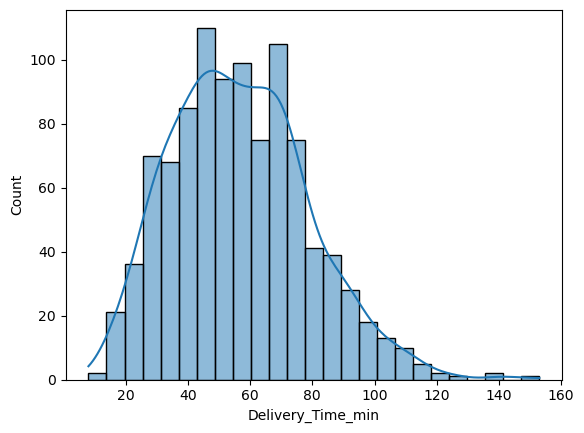

In [15]:
sns.histplot(df['Delivery_Time_min'], kde=True)
plt.show()

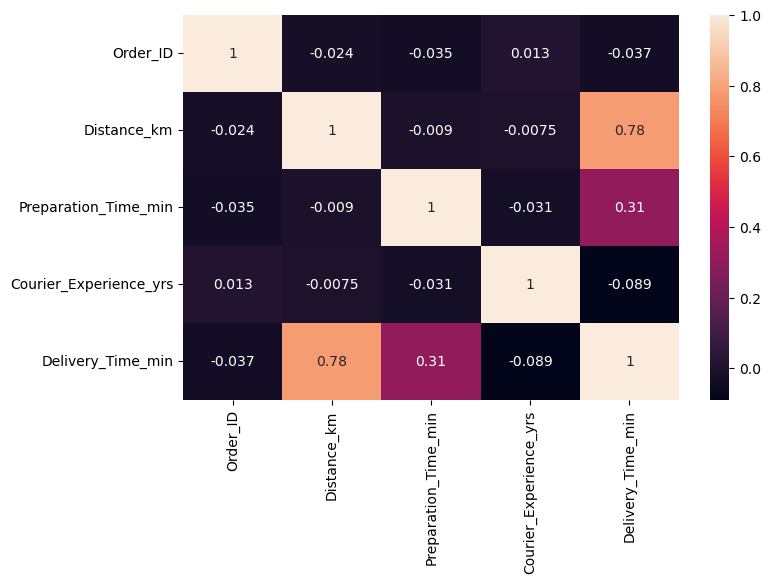

In [16]:
num_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,5))
sns.heatmap(num_df.corr(), annot=True)
plt.show()

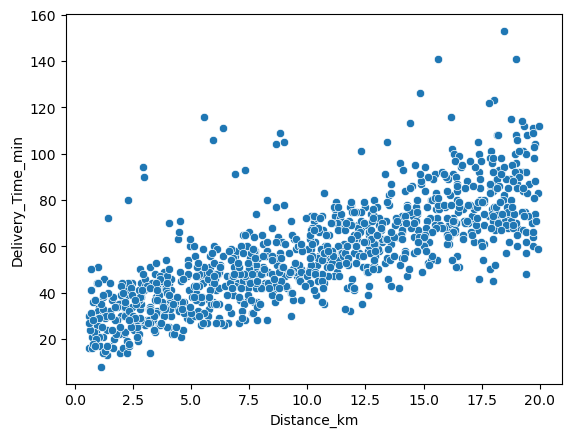

In [17]:
sns.scatterplot(
    x='Distance_km',
    y='Delivery_Time_min',
    data=df
)
plt.show()

<Axes: xlabel='Delivery_Time_min'>

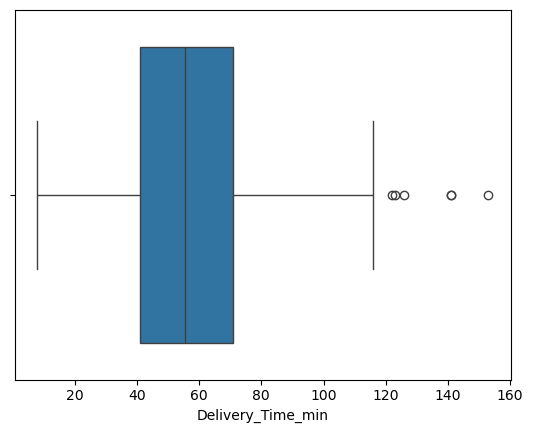

In [18]:
sns.boxplot(
    x=df['Delivery_Time_min']
)

In [19]:
df = pd.get_dummies(
    df,
    columns=[
        'Weather',
        'Traffic_Level',
        'Time_of_Day',
        'Vehicle_Type'
    ],
    drop_first=True
)

In [21]:
X = df.drop(
    ['Order_ID','Delivery_Time_min'],
    axis=1
)

y = df['Delivery_Time_min']

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Create model
mlr_model = LinearRegression()

# Train model
mlr_model.fit(X_train, y_train)

# Predictions
y_pred_mlr = mlr_model.predict(X_test)

# Metrics
train_r2 = mlr_model.score(X_train, y_train)
test_r2 = r2_score(y_test, y_pred_mlr)


In [35]:
print("Intercept:", mlr_model.intercept_)
print("Coefficients:", mlr_model.coef_)

Intercept: 17.367578505419083
Coefficients: [  3.00130351   0.96915803  -0.67716491   5.81645249   4.6394454
   9.24681597   1.44694713 -11.12562875  -5.45358432   1.00478358
  -0.16927376  -1.37548279   0.51772916  -0.93497255]


In [36]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': mlr_model.coef_
})

coef_df.sort_values(
    by='Coefficient',
    ascending=False
)

,Feature,Coefficient
5,Weather_Snowy,9.246816
3,Weather_Foggy,5.816452
4,Weather_Rainy,4.639445
0,Distance_km,3.001304
6,Weather_Windy,1.446947
9,Time_of_Day_Evening,1.004784
1,Preparation_Time_min,0.969158
12,Vehicle_Type_Car,0.517729
10,Time_of_Day_Morning,-0.169274
2,Courier_Experience_yrs,-0.677165


In [37]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

print("MAE :", mean_absolute_error(y_test, y_pred_mlr))

print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_mlr)))

print("Train R2 :", train_r2)
print("Test R2  :", test_r2)

MAE : 5.8991686983534874
RMSE : 8.826470149873378
Train R2 : 0.7630020365990979
Test R2  : 0.8261894538886113


In [38]:
from sklearn.model_selection import cross_val_score

mlr = LinearRegression()

mlr_cv_scores = cross_val_score(
    mlr,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("Fold Scores:")
print(mlr_cv_scores)

print("\nAverage R2:")
print(mlr_cv_scores.mean())

Fold Scores:
[0.70307888 0.80689978 0.78757919 0.75516701 0.78994626]

Average R2:
0.7685342237868473


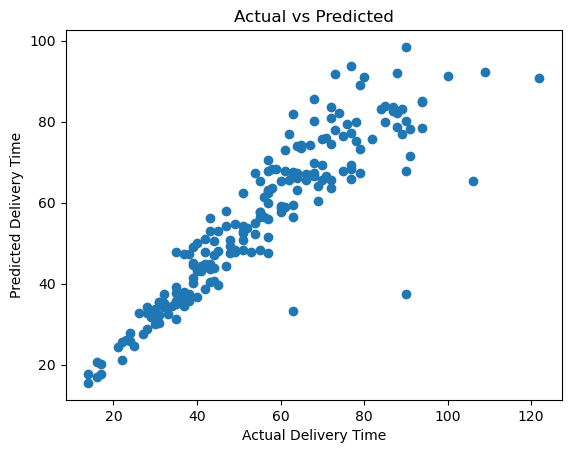

In [39]:
plt.scatter(y_test, y_pred_mlr)
plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Delivery Time")
plt.title("Actual vs Predicted")
plt.show()

In [40]:
import joblib

joblib.dump(mlr_model,
            "food_delivery_model.pkl")

['food_delivery_model.pkl']